<a href="https://colab.research.google.com/github/zarasari/multi-domain-treatment-analysis/blob/main/ww_Treatment_Attributes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# There are various ways to deal with multidimensional comparisons on a two-dimensional display. See the pros and cons of radar charts, heat maps, trade-off plots and contour maps.

url = "https://raw.githubusercontent.com/VIS-SIG/Wonderful-Wednesdays/master/data/2026/2026-02-11/simulated_cdi_dataset.xlsx"

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_excel(url, engine="openpyxl")

change domain labels

In [ ]:
label_map = {
    "VS": "Vital Signs",
    "PS": "Physical Symptoms",
    "EW": "Emotional Wellbeing",
    "SE": "Side Effects",
    "TA": "Treatment Administration"
}

In [ ]:
data.head()

,USUBJID,TRTP,AVISIT,PARAMCD,AVAL
0,SUBJECT-001,Treatment D,Baseline,VS,85
1,SUBJECT-001,Treatment D,Baseline,PS,50
2,SUBJECT-001,Treatment D,Baseline,EW,33
3,SUBJECT-001,Treatment D,Baseline,SE,64
4,SUBJECT-001,Treatment D,Baseline,TA,80


average scores by treatment and domain

In [ ]:
data.groupby(["TRTP","PARAMCD"])["AVAL"].mean().reset_index()

,TRTP,PARAMCD,AVAL
0,Treatment A,EW,61.463918
1,Treatment A,PS,45.216495
2,Treatment A,SE,43.687285
3,Treatment A,TA,46.883162
4,Treatment A,VS,50.931271
5,Treatment B,EW,49.261168
6,Treatment B,PS,57.353952
7,Treatment B,SE,51.199313
8,Treatment B,TA,47.261168
9,Treatment B,VS,59.536082


# Create separate visit datasets

In [ ]:
baseline = data[data["AVISIT"] == "Baseline"].copy()
month6   = data[data["AVISIT"] == "Month 6"].copy()
month12  = data[data["AVISIT"] == "Month 12"].copy()

# Heatmaps for Month 6 and Month 12





In [ ]:
domain_order = ["VS", "PS", "EW", "SE", "TA"]

domain_labels = {
    "VS": "Vital Signs",
    "PS": "Physical Symptoms",
    "EW": "Emotional Wellbeing",
    "SE": "Side Effects",
    "TA": "Treatment Admin"
}

treatment_order = ["Treatment A", "Treatment B", "Treatment C", "Treatment D", "Treatment E"]

def make_heatmap(df, title, filename=None):

    summary = (
        df.groupby(["TRTP", "PARAMCD"])["AVAL"]
        .mean()
        .reset_index()
        .pivot(index="TRTP", columns="PARAMCD", values="AVAL")
        .reindex(index=treatment_order, columns=domain_order)
    )

    summary = summary.rename(columns=domain_labels)

    plt.figure(figsize=(10,4.8))
    sns.heatmap(summary, annot=True, fmt=".1f", cmap="RdYlGn_r", vmin=0, vmax=100)

    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Treatment")
    plt.xticks(rotation=20, ha="right")

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    return summary

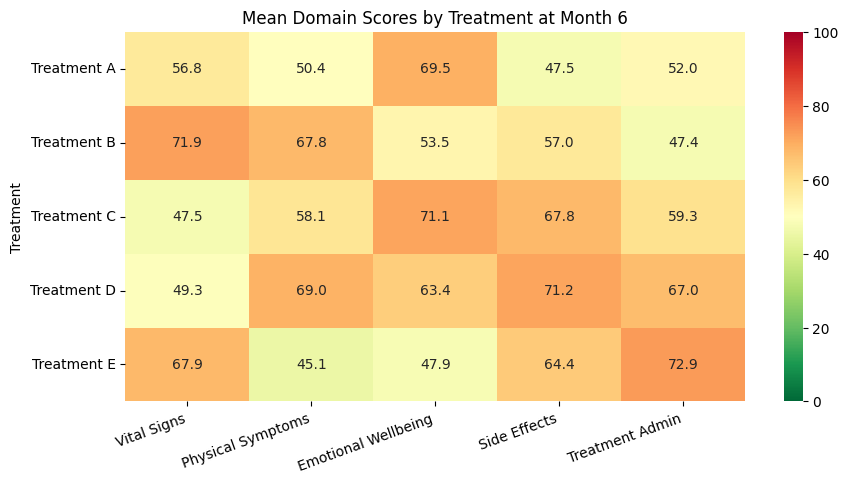

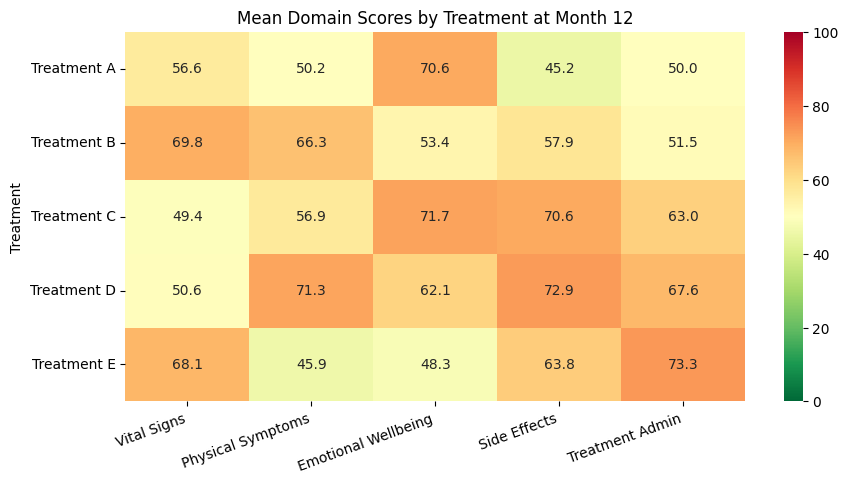

In [ ]:
month6_summary = make_heatmap(
    month6,
    "Mean Domain Scores by Treatment at Month 6",
    "month6_heatmap.png"
)

month12_summary = make_heatmap(
    month12,
    "Mean Domain Scores by Treatment at Month 12",
    "month12_heatmap.png"
)

# Calculate change from baseline

In [ ]:
wide = (
    data.pivot_table(
        index=["USUBJID", "TRTP", "PARAMCD"],
        columns="AVISIT",
        values="AVAL"
    )
    .reset_index()
)

wide.head()

AVISIT,USUBJID,TRTP,PARAMCD,Baseline,Month 12,Month 6
0,SUBJECT-001,Treatment D,EW,33.0,53.0,72.0
1,SUBJECT-001,Treatment D,PS,50.0,83.0,60.0
2,SUBJECT-001,Treatment D,SE,64.0,100.0,94.0
3,SUBJECT-001,Treatment D,TA,80.0,100.0,92.0
4,SUBJECT-001,Treatment D,VS,85.0,88.0,80.0


# calculate change:

In [ ]:
wide["chg_m6"] = wide["Month 6"] - wide["Baseline"]
wide["chg_m12"] = wide["Month 12"] - wide["Baseline"]

# Heatmaps for change from baseline

In [ ]:
def make_change_heatmap(df, value_col, title, filename=None):

    summary = (
        df.groupby(["TRTP", "PARAMCD"])[value_col]
        .mean()
        .reset_index()
        .pivot(index="TRTP", columns="PARAMCD", values=value_col)
        .reindex(index=treatment_order, columns=domain_order)
    )

    summary = summary.rename(columns=domain_labels)

    plt.figure(figsize=(10,4.8))
    sns.heatmap(summary, annot=True, fmt=".1f", cmap="RdYlGn", center=0)

    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Treatment")
    plt.xticks(rotation=20, ha="right")

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    return summary

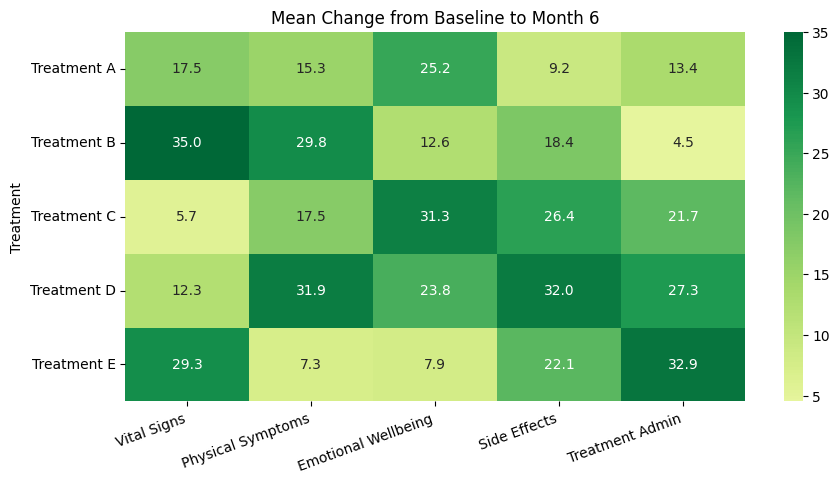

In [ ]:
chg6_summary = make_change_heatmap(
    wide,
    "chg_m6",
    "Mean Change from Baseline to Month 6",
    "chg6_heatmap.png"
)

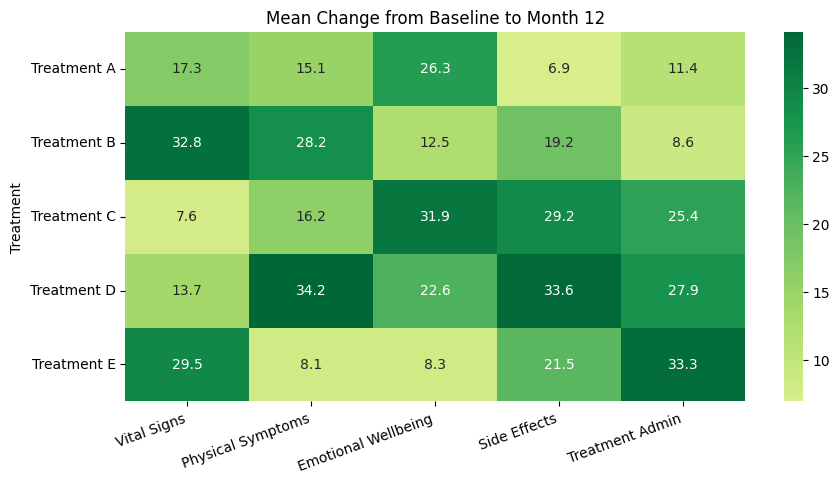

In [ ]:
chg6_summary = make_change_heatmap(
    wide,
    "chg_m12",
    "Mean Change from Baseline to Month 12",
    "chg12_heatmap.png"
)

# Build weighted preference profiles

In [ ]:
month12_summary

PARAMCD,Vital Signs,Physical Symptoms,Emotional Wellbeing,Side Effects,Treatment Admin
TRTP,,,,,
Treatment A,56.628866,50.164948,70.608247,45.247423,50.010309
Treatment B,69.752577,66.257732,53.371134,57.876289,51.505155
Treatment C,49.377551,56.857143,71.653061,70.632653,62.969388
Treatment D,50.633028,71.275229,62.146789,72.862385,67.596330
Treatment E,68.050505,45.898990,48.292929,63.767677,73.282828


In [ ]:
preference_profiles = {
    "Equal": {
        "Vital Signs":1,
        "Physical Symptoms":1,
        "Emotional Wellbeing":1,
        "Side Effects":1,
        "Treatment Admin":1
    },
    "Symptoms focus": {
        "Vital Signs":1,
        "Physical Symptoms":4,
        "Emotional Wellbeing":1,
        "Side Effects":1,
        "Treatment Admin":1
    },
    "Emotional focus": {
        "Vital Signs":1,
        "Physical Symptoms":1,
        "Emotional Wellbeing":4,
        "Side Effects":1,
        "Treatment Admin":1
    },
    "Side effects": {
        "Vital Signs":1,
        "Physical Symptoms":1,
        "Emotional Wellbeing":1,
        "Side Effects":4,
        "Treatment Admin":1
    },
    "Convenience": {
        "Vital Signs":1,
        "Physical Symptoms":1,
        "Emotional Wellbeing":1,
        "Side Effects":1,
        "Treatment Admin":4
    }
}

In [ ]:
weighted_results = {}

for profile_name, weights in preference_profiles.items():
    weight_series = pd.Series(weights)
    weighted_score = month12_summary.mul(weight_series, axis=1).sum(axis=1) / weight_series.sum()
    weighted_results[profile_name] = weighted_score

weighted_results_df = pd.DataFrame(weighted_results)
weighted_results_df

,Equal,Symptoms focus,Emotional focus,Side effects,Convenience
TRTP,,,,,
Treatment A,54.531959,52.894330,60.560567,51.050258,52.836340
Treatment B,59.752577,62.192010,57.359536,59.048969,56.659794
Treatment C,62.297959,60.257653,65.806122,65.423469,62.549745
Treatment D,64.902752,67.292431,63.869266,67.887615,65.912844
Treatment E,59.858586,54.623737,55.521465,61.324495,64.892677


# Plot weighted treatment scores

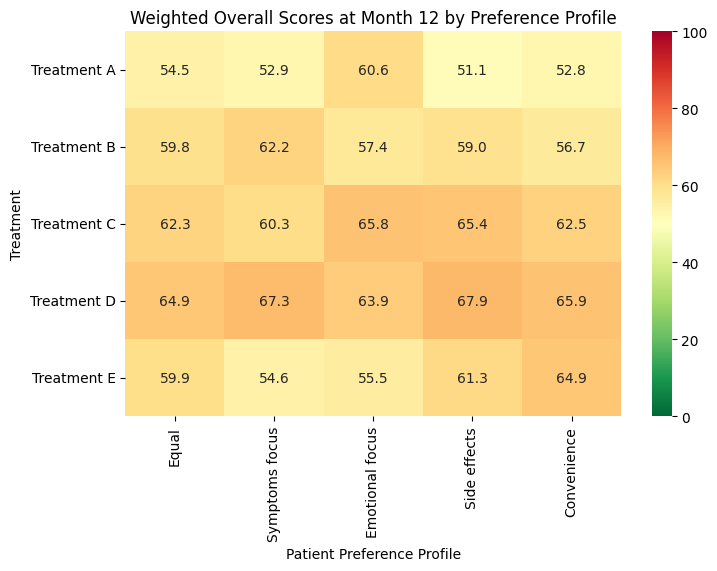

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(weighted_results_df, annot=True, fmt=".1f", cmap="RdYlGn_r", vmin=0, vmax=100)
plt.title("Weighted Overall Scores at Month 12 by Preference Profile")
plt.xlabel("Patient Preference Profile")
plt.ylabel("Treatment")
plt.savefig("weighted_preference.png", dpi=300, bbox_inches="tight")
plt.show()

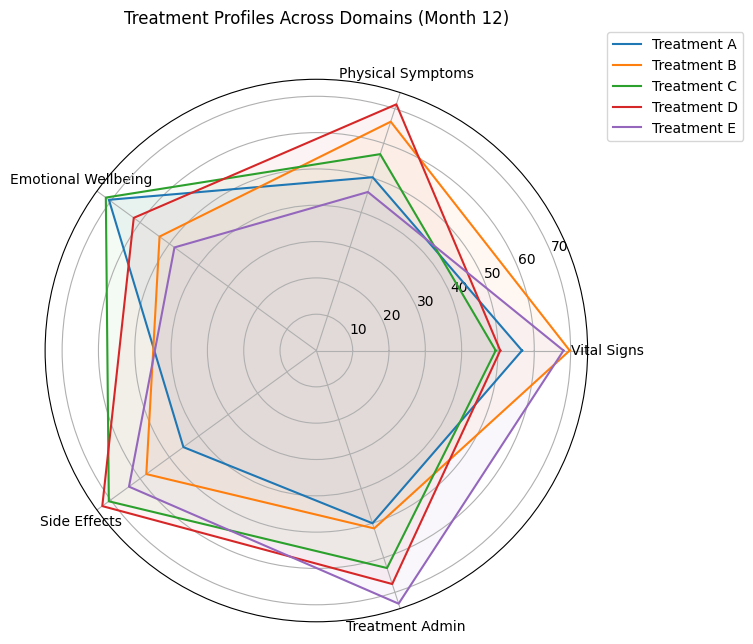

In [ ]:
import numpy as np

labels = month12_summary.columns.tolist()
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

for treatment in month12_summary.index:

    values = month12_summary.loc[treatment].tolist()
    values += values[:1]

    ax.plot(angles, values, label=treatment)
    ax.fill(angles, values, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_title("Treatment Profiles Across Domains (Month 12)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))
ax.set_title("Treatment Profiles Across Domains (Month 12)", pad=40)
plt.subplots_adjust(top=0.9)
plt.savefig("treatment_across_domains.png", dpi=300, bbox_inches="tight")
plt.show()

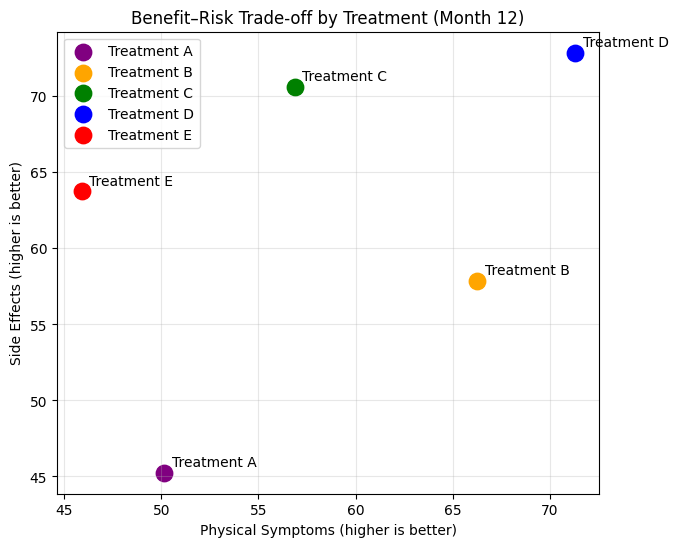

In [ ]:
plt.figure(figsize=(7,6))

palette = {
    "Treatment A": "purple",
    "Treatment B": "orange",
    "Treatment C": "green",
    "Treatment D": "blue",
    "Treatment E": "red"
}

for treatment in month12_summary.index:
    plt.scatter(
        month12_summary.loc[treatment, "Physical Symptoms"],
        month12_summary.loc[treatment, "Side Effects"],
        s=140,
        label=treatment,
        color=palette[treatment]
    )

    plt.text(
        month12_summary.loc[treatment, "Physical Symptoms"] + 0.4,
        month12_summary.loc[treatment, "Side Effects"] + 0.4,
        treatment
    )

plt.xlabel("Physical Symptoms (higher is better)")
plt.ylabel("Side Effects (higher is better)")
plt.title("Benefit–Risk Trade-off by Treatment (Month 12)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("benefit_risk_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
rank_df = weighted_results_df.rank(method="min", ascending=True)

plt.figure(figsize=(8, 5))
sns.heatmap(rank_df, annot=True, fmt=".0f", cmap="YlGnBu_r", vmin=1, vmax=5)
plt.title("Treatment Ranking by Patient Preference Profile")
plt.xlabel("Patient Preference Profile")
plt.ylabel("Treatment")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(data=data, x="PARAMCD", y="AVAL", hue="TRTP")

plt.title("Disease Domain Scores by Treatment")
plt.show()

In [ ]:
followup = data[data["AVISIT"] != "Baseline"]

plt.figure(figsize=(10,6))
sns.boxplot(data=followup, x="PARAMCD", y="AVAL", hue="TRTP")
plt.title("Follow-up Disease Domain Scores by Treatment")
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
sns.pointplot(data=followup, x="PARAMCD", y="AVAL", hue="TRTP", dodge=0.3, errorbar="sd")
plt.title("Mean Follow-up Scores by Domain and Treatment")
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
sns.pointplot(data=followup, x="PARAMCD", y="AVAL", hue="TRTP", dodge=0.3, errorbar="sd")
plt.title("Mean Follow-up Scores by Domain and Treatment")
plt.show()

In [ ]:
data["AVISIT"].value_counts()

In [ ]:
summary = (
    followup.groupby(["TRTP", "PARAMCD"])["AVAL"]
    .mean()
    .reset_index()
    .pivot(index="TRTP", columns="PARAMCD", values="AVAL")
)

plt.figure(figsize=(8,4))
sns.heatmap(summary, annot=True, cmap="RdYlGn_r")
plt.title("Mean Follow-up Scores by Treatment and Domain")
plt.show()

Weighted Composite Score